<a href="https://colab.research.google.com/github/EcTrailblazers/python-data-projects/blob/main/02_ecommerce_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

raw_data = """OrderID,Product,UnitPrice,Quantity,OrderDate,CustomerRegion
1001,Wireless Mouse,25.99,2,2026-01-05, North
1002,Mechanical Keyboard,89.50,1,2026-01-07,South
1003,USB-C Hub,34.00,-1,2026-01-08,West
1004,27-inch Monitor,249.99,2,2026-01-12,East
1005,Mechanical Keyboard,89.50,3,2026-01-15,north
1001,Wireless Mouse,25.99,2,2026-01-05, North
1006,Noise-Cancelling Headphones,199.99,1,2026-01-18,
1007,Laptop Stand,39.99,4,2026-01-20,South
1008,Webcam 1080p,59.00,0,2026-01-22,East
1009,Wireless Mouse,25.99,5,2026-01-25,West
1010,27-inch Monitor,249.99,1,2026-01-28,North
1011,USB-C Hub,34.00,3,2026-01-30,SOUTH
1012,Mechanical Keyboard,89.50,2,2026-02-02,East
1013,Noise-Cancelling Headphones,199.99,-2,2026-02-05,West
1014,Laptop Stand,39.99,2,2026-02-08,North
"""

with open("ecommerce_orders.csv", "w") as f:
    f.write(raw_data.strip())

print("ecommerce_orders.csv created successfully.")

ecommerce_orders.csv created successfully.


In [2]:
# Step 2: Load and inspect the dataset
df_orders = pd.read_csv("ecommerce_orders.csv")

print("--- First 5 Records ---")
print(df_orders.head())

print("\n--- Data Structure & Missing Values ---")
print(df_orders.info())

print("\n--- Statistical Overview ---")
print(df_orders.describe())

--- First 5 Records ---
   OrderID              Product  UnitPrice  Quantity   OrderDate  \
0     1001       Wireless Mouse      25.99         2  2026-01-05   
1     1002  Mechanical Keyboard      89.50         1  2026-01-07   
2     1003            USB-C Hub      34.00        -1  2026-01-08   
3     1004      27-inch Monitor     249.99         2  2026-01-12   
4     1005  Mechanical Keyboard      89.50         3  2026-01-15   

  CustomerRegion  
0         North   
1          South  
2           West  
3           East  
4          north  

--- Data Structure & Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   OrderID         15 non-null     int64  
 1   Product         15 non-null     object 
 2   UnitPrice       15 non-null     float64
 3   Quantity        15 non-null     int64  
 4   OrderDate       15 non-null     obj

In [3]:
# Step 3: Clean data and create TotalRevenue column

# 1. Remove duplicate transaction IDs
df_clean = df_orders.drop_duplicates(subset=["OrderID"]).copy()

# 2. Keep only valid purchases (positive quantities)
df_clean = df_clean[df_clean["Quantity"] > 0]

# 3. Standardize text in CustomerRegion
df_clean["CustomerRegion"] = (
    df_clean["CustomerRegion"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .str.title()
)

# 4. Cast dates to datetime objects
df_clean["OrderDate"] = pd.to_datetime(df_clean["OrderDate"])

# 5. Compute derived business metric: Total Revenue
df_clean["TotalRevenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

# 6. Sort by order date
df_clean = df_clean.sort_values(by="OrderDate").reset_index(drop=True)

print("--- Cleaned DataFrame Preview ---")
print(df_clean[["OrderID", "OrderDate", "Product", "Quantity", "TotalRevenue", "CustomerRegion"]])

--- Cleaned DataFrame Preview ---
    OrderID  OrderDate                      Product  Quantity  TotalRevenue  \
0      1001 2026-01-05               Wireless Mouse         2         51.98   
1      1002 2026-01-07          Mechanical Keyboard         1         89.50   
2      1004 2026-01-12              27-inch Monitor         2        499.98   
3      1005 2026-01-15          Mechanical Keyboard         3        268.50   
4      1006 2026-01-18  Noise-Cancelling Headphones         1        199.99   
5      1007 2026-01-20                 Laptop Stand         4        159.96   
6      1009 2026-01-25               Wireless Mouse         5        129.95   
7      1010 2026-01-28              27-inch Monitor         1        249.99   
8      1011 2026-01-30                    USB-C Hub         3        102.00   
9      1012 2026-02-02          Mechanical Keyboard         2        179.00   
10     1014 2026-02-08                 Laptop Stand         2         79.98   

   CustomerRegion

In [4]:
# 1. High-level financial KPIs
total_gross_revenue = df_clean["TotalRevenue"].sum()
total_units_sold = df_clean["Quantity"].sum()
avg_order_value = df_clean["TotalRevenue"].mean()

print(f"Total Gross Revenue: ${total_gross_revenue:,.2f}")
print(f"Total Units Sold:    {total_units_sold}")
print(f"Average Order Value: ${avg_order_value:.2f}")

# 2. Product-level breakdown: total sales and units sold
product_performance = (
    df_clean.groupby("Product")
    .agg(
        TotalRevenue=("TotalRevenue", "sum"), UnitsSold=("Quantity", "sum")
    )
    .sort_values(by="TotalRevenue", ascending=False)
)

print("\n--- Product Performance ---")
print(product_performance)

# 3. Regional breakdown: total revenue by territory
regional_sales = (
    df_clean.groupby("CustomerRegion")["TotalRevenue"]
    .sum()
    .sort_values(ascending=False)
)

print("\n--- Sales by Customer Region ---")
print(regional_sales)

Total Gross Revenue: $2,010.83
Total Units Sold:    26
Average Order Value: $182.80

--- Product Performance ---
                             TotalRevenue  UnitsSold
Product                                             
27-inch Monitor                    749.97          3
Mechanical Keyboard                537.00          6
Laptop Stand                       239.94          6
Noise-Cancelling Headphones        199.99          1
Wireless Mouse                     181.93          7
USB-C Hub                          102.00          3

--- Sales by Customer Region ---
CustomerRegion
East       678.98
North      650.45
South      351.46
Unknown    199.99
West       129.95
Name: TotalRevenue, dtype: float64


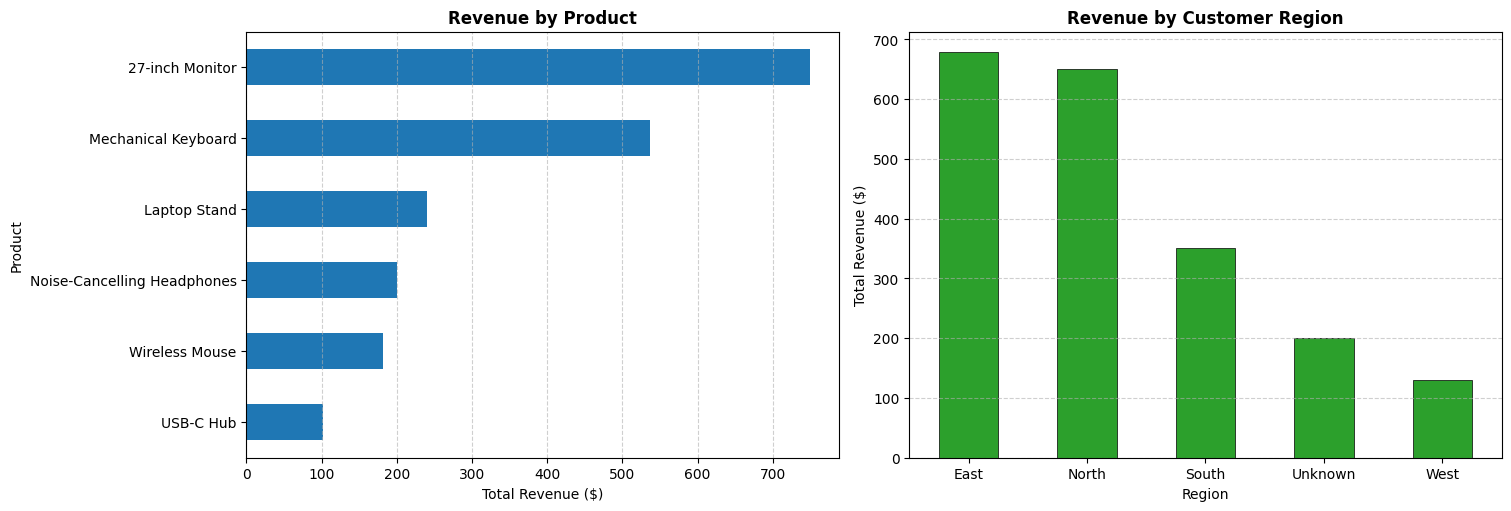

In [5]:
# Single-cell execution for complete dashboard
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), layout="constrained")

# Chart 1: Revenue by Product (Horizontal Bar)
product_revenue = product_performance["TotalRevenue"].sort_values()
product_revenue.plot(kind="barh", color="#1f77b4", ax=ax1)
ax1.set_title("Revenue by Product", fontsize=12, weight="bold")
ax1.set_xlabel("Total Revenue ($)")
ax1.set_ylabel("Product")
ax1.grid(axis="x", linestyle="--", alpha=0.6)

# Chart 2: Revenue by Customer Region (Vertical Bar)
regional_sales.plot(
    kind="bar", color="#2ca02c", ax=ax2, edgecolor="black", linewidth=0.5
)
ax2.set_title("Revenue by Customer Region", fontsize=12, weight="bold")
ax2.set_xlabel("Region")
ax2.set_ylabel("Total Revenue ($)")
ax2.tick_params(axis="x", rotation=0)
ax2.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()